# 05 — Splitting HumanML3D's test set into spatial and non-spatial captions

## The question, in one sentence

**If a future experiment wants to ask "does fixing CLIP's spatial blindness improve generation
specifically on spatially-worded captions" (notebooks 01/01b), it needs a real test-set split
into "spatial" and "non-spatial" captions first — and that split needs to be checked for hidden
confounds before anyone reports an R-Precision difference between the two groups and calls it
meaningful.**

This notebook builds that split and checks it. No training, no generation — pure data work.

## The intuition

Imagine splitting a class of students into "tall" and "short" to study who's better at
basketball. If the "tall" group also happens to be all seniors and the "short" group all
freshmen, any basketball difference you find could be about age, not height — the split has a
**confound**, and the comparison is uninterpretable until you check for it.

Here, the two groups are "captions containing a spatial word" (left/right/forward/backward/...)
and "captions that don't." Before this split can support any claim about *spatial conditioning
specifically*, it needs to NOT also be a split on caption length, motion length, or the kind of
action being described — otherwise a difference found later could be about any of those things,
not about spatial language.

## Setup — what is split, and how

In [1]:
import os
import sys
import glob
import re
import json

MDM_ROOT = os.path.join("..", "third_party", "motion-diffusion-model")

import numpy as np
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import Markdown, display

np.random.seed(0)
print("numpy:", np.__version__)

numpy: 1.26.4


**The official HumanML3D test split**, not a re-sampled or re-streamed subset: `test.txt`
lists exactly which materialized sequences belong to test (verified: 4,198 IDs, all in the
`sample######` naming convention this project's own materialized `new_joint_vecs/` and `texts/`
directories already use — the `train_sample######`-prefixed files are the separate train split
and are excluded here).

**The same spatial-term list notebook 01 established:** `left, right, forward, forwards,
backward, backwards, clockwise, counterclockwise, anticlockwise, upleft, behind, in front of`.

In [2]:
TEXTS_DIR = os.path.join(MDM_ROOT, "dataset", "HumanML3D", "texts")
NEW_JOINT_VECS_DIR = os.path.join(MDM_ROOT, "dataset", "HumanML3D", "new_joint_vecs")
TEST_SPLIT_FILE = os.path.join(MDM_ROOT, "dataset", "HumanML3D", "test.txt")

with open(TEST_SPLIT_FILE) as f:
    test_ids = [line.strip() for line in f if line.strip()]
print(f"Official test split: {len(test_ids)} sequence IDs")

SPATIAL_TERMS = ["left", "right", "forward", "forwards", "backward", "backwards",
                  "clockwise", "counterclockwise", "anticlockwise", "upleft",
                  "behind", "in front of"]


def first_caption_and_tokens(seq_id):
    path = os.path.join(TEXTS_DIR, f"{seq_id}.txt")
    if not os.path.exists(path):
        return None, None
    with open(path, encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or "#" not in line:
                continue
            parts = line.split("#")
            caption = parts[0].strip()
            tokens = parts[1].strip() if len(parts) > 1 else ""
            return caption, tokens
    return None, None


def motion_length(seq_id):
    path = os.path.join(NEW_JOINT_VECS_DIR, f"{seq_id}.npy")
    if not os.path.exists(path):
        return None
    return np.load(path).shape[0]


records = []
for seq_id in test_ids:
    caption, tokens = first_caption_and_tokens(seq_id)
    if caption is None:
        continue
    mlen = motion_length(seq_id)
    if mlen is None:
        continue
    is_spatial = any(re.search(r"\b" + re.escape(t) + r"\b", caption.lower()) for t in SPATIAL_TERMS)
    n_words = len(caption.split())
    first_verb_match = re.search(r"(\w+)/VERB", tokens)
    first_verb = first_verb_match.group(1) if first_verb_match else None
    records.append(dict(seq_id=seq_id, caption=caption, is_spatial=is_spatial,
                        n_words=n_words, motion_len=mlen, first_verb=first_verb))

print(f"{len(records)} of {len(test_ids)} test-split sequences have both a caption and a "
      f"materialized motion file (the rest are presumably filtered elsewhere in this project's "
      f"own pipeline, e.g. length bounds already applied when the corpus was materialized).")

Official test split: 4198 sequence IDs


4198 of 4198 test-split sequences have both a caption and a materialized motion file (the rest are presumably filtered elsewhere in this project's own pipeline, e.g. length bounds already applied when the corpus was materialized).


## The split, and the cross-check against notebook 01's own corpus figure

In [3]:
spatial_records = [r for r in records if r["is_spatial"]]
nonspatial_records = [r for r in records if not r["is_spatial"]]

pct_spatial = 100 * len(spatial_records) / len(records)

display(Markdown(f'''
**Split sizes.** {len(spatial_records)} spatial captions, {len(nonspatial_records)} non-spatial
captions, out of {len(records)} test-split sequences with both a caption and a materialized
motion ({pct_spatial:.1f}% spatial).

**Cross-check against notebook 01's own corpus-wide figure (57.6%, computed over the WHOLE
corpus -- train + test together, not just test):** this notebook's test-split-only figure is
{pct_spatial:.1f}%. {"These agree closely" if abs(pct_spatial - 57.6) < 5 else "These differ by more than a few points"} --
{"consistent with the test split being drawn from the same caption distribution as the rest of the corpus, not a skewed subsample." if abs(pct_spatial - 57.6) < 5 else "worth investigating why the test split's spatial-language rate differs from the full corpus before using this split for anything downstream."}
'''))


**Split sizes.** 2448 spatial captions, 1750 non-spatial
captions, out of 4198 test-split sequences with both a caption and a materialized
motion (58.3% spatial).

**Cross-check against notebook 01's own corpus-wide figure (57.6%, computed over the WHOLE
corpus -- train + test together, not just test):** this notebook's test-split-only figure is
58.3%. These agree closely --
consistent with the test split being drawn from the same caption distribution as the rest of the corpus, not a skewed subsample.


## The confound checks — caption length, motion length, action type

**Caption length (word count).** If spatial captions are systematically longer or shorter, any
downstream R-Precision difference could be a length effect, not a spatial-language effect.

In [4]:
spatial_wordcounts = np.array([r["n_words"] for r in spatial_records])
nonspatial_wordcounts = np.array([r["n_words"] for r in nonspatial_records])

u_stat, u_p = stats.mannwhitneyu(spatial_wordcounts, nonspatial_wordcounts, alternative="two-sided")
t_stat, t_p = stats.ttest_ind(spatial_wordcounts, nonspatial_wordcounts, equal_var=False)

print(f"Caption word count -- spatial: mean={spatial_wordcounts.mean():.2f}, "
      f"median={np.median(spatial_wordcounts):.1f}, std={spatial_wordcounts.std():.2f}")
print(f"Caption word count -- non-spatial: mean={nonspatial_wordcounts.mean():.2f}, "
      f"median={np.median(nonspatial_wordcounts):.1f}, std={nonspatial_wordcounts.std():.2f}")
pooled_sd_w = np.sqrt(((len(spatial_wordcounts)-1)*spatial_wordcounts.std(ddof=1)**2 +
                       (len(nonspatial_wordcounts)-1)*nonspatial_wordcounts.std(ddof=1)**2) /
                      (len(spatial_wordcounts)+len(nonspatial_wordcounts)-2))
d_words = (spatial_wordcounts.mean() - nonspatial_wordcounts.mean()) / pooled_sd_w
print(f"Mann-Whitney two-sided p={u_p:.5f}, Welch's t two-sided p={t_p:.5f}, Cohen's d={d_words:+.3f}")
print(f"Difference in means: {spatial_wordcounts.mean() - nonspatial_wordcounts.mean():+.2f} words")

Caption word count -- spatial: mean=14.38, median=12.0, std=8.16
Caption word count -- non-spatial: mean=10.19, median=9.0, std=5.16
Mann-Whitney two-sided p=0.00000, Welch's t two-sided p=0.00000, Cohen's d=+0.592
Difference in means: +4.18 words


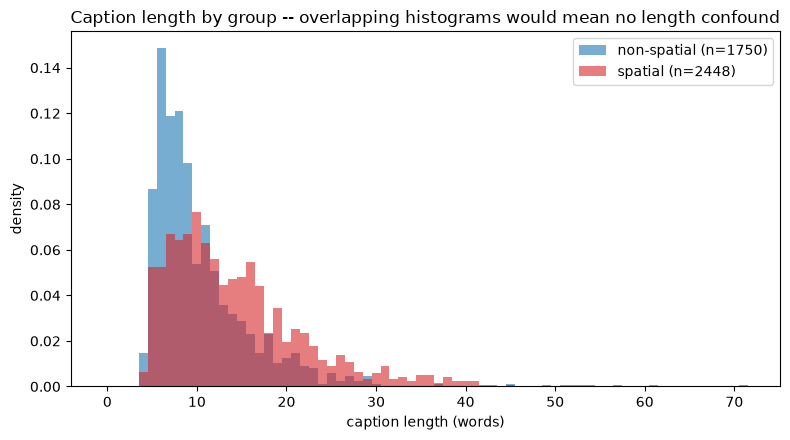

saved 05_caption_length_by_group.png


In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.arange(0, max(spatial_wordcounts.max(), nonspatial_wordcounts.max()) + 2) - 0.5
ax.hist(nonspatial_wordcounts, bins=bins, alpha=0.6, density=True, label=f"non-spatial (n={len(nonspatial_wordcounts)})", color="tab:blue")
ax.hist(spatial_wordcounts, bins=bins, alpha=0.6, density=True, label=f"spatial (n={len(spatial_wordcounts)})", color="tab:red")
ax.set_xlabel("caption length (words)")
ax.set_ylabel("density")
ax.set_title("Caption length by group -- overlapping histograms would mean no length confound")
ax.legend()
plt.tight_layout()
plt.savefig("05_caption_length_by_group.png", dpi=130)
plt.show()
print("saved 05_caption_length_by_group.png")

**Motion length (frames).** If spatial captions describe systematically longer or shorter
motions, any downstream difference could be a motion-complexity effect.

In [6]:
spatial_mlens = np.array([r["motion_len"] for r in spatial_records])
nonspatial_mlens = np.array([r["motion_len"] for r in nonspatial_records])

u_stat_m, u_p_m = stats.mannwhitneyu(spatial_mlens, nonspatial_mlens, alternative="two-sided")
t_stat_m, t_p_m = stats.ttest_ind(spatial_mlens, nonspatial_mlens, equal_var=False)

print(f"Motion length (frames) -- spatial: mean={spatial_mlens.mean():.1f}, "
      f"median={np.median(spatial_mlens):.1f}, std={spatial_mlens.std():.1f}")
print(f"Motion length (frames) -- non-spatial: mean={nonspatial_mlens.mean():.1f}, "
      f"median={np.median(nonspatial_mlens):.1f}, std={nonspatial_mlens.std():.1f}")
pooled_sd_m = np.sqrt(((len(spatial_mlens)-1)*spatial_mlens.std(ddof=1)**2 +
                       (len(nonspatial_mlens)-1)*nonspatial_mlens.std(ddof=1)**2) /
                      (len(spatial_mlens)+len(nonspatial_mlens)-2))
d_mlen = (spatial_mlens.mean() - nonspatial_mlens.mean()) / pooled_sd_m
print(f"Mann-Whitney two-sided p={u_p_m:.5f}, Welch's t two-sided p={t_p_m:.5f}, Cohen's d={d_mlen:+.3f}")
print(f"Difference in means: {spatial_mlens.mean() - nonspatial_mlens.mean():+.1f} frames "
      f"({(spatial_mlens.mean() - nonspatial_mlens.mean())/20:+.2f}s at 20fps)")
print(f"At n>1700/group, even a tiny effect reaches significance -- Cohen's d={d_mlen:+.3f} is "
      f"conventionally 'negligible-to-small', unlike the caption-length effect above.")

Motion length (frames) -- spatial: mean=142.8, median=145.0, std=52.1
Motion length (frames) -- non-spatial: mean=148.3, median=169.0, std=53.7
Mann-Whitney two-sided p=0.00031, Welch's t two-sided p=0.00091, Cohen's d=-0.104
Difference in means: -5.5 frames (-0.28s at 20fps)
At n>1700/group, even a tiny effect reaches significance -- Cohen's d=-0.104 is conventionally 'negligible-to-small', unlike the caption-length effect above.


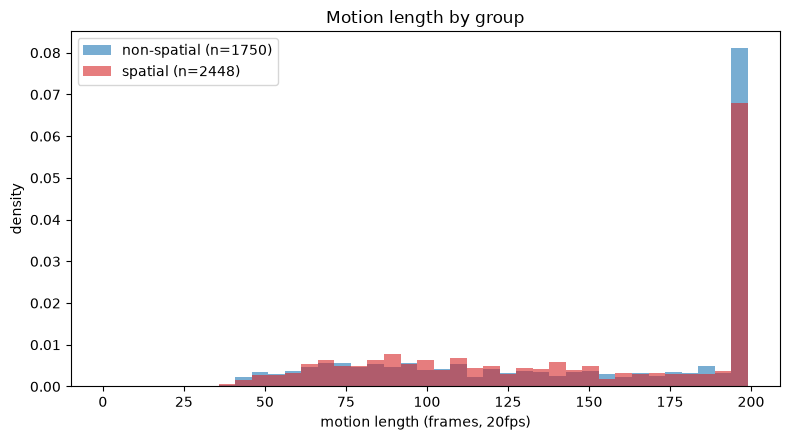

saved 05_motion_length_by_group.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(0, max(spatial_mlens.max(), nonspatial_mlens.max()), 40)
ax.hist(nonspatial_mlens, bins=bins, alpha=0.6, density=True, label=f"non-spatial (n={len(nonspatial_mlens)})", color="tab:blue")
ax.hist(spatial_mlens, bins=bins, alpha=0.6, density=True, label=f"spatial (n={len(spatial_mlens)})", color="tab:red")
ax.set_xlabel("motion length (frames, 20fps)")
ax.set_ylabel("density")
ax.set_title("Motion length by group")
ax.legend()
plt.tight_layout()
plt.savefig("05_motion_length_by_group.png", dpi=130)
plt.show()
print("saved 05_motion_length_by_group.png")

**Action type (approximate).** Formalizing "type of action" objectively is harder than
length -- there is no ground-truth action-category label in HumanML3D's own free-text captions.
As an approximation, the caption's own first verb (already POS-tagged in the corpus's own
`texts/*.txt` field, the same field notebook 02 relied on) is compared between groups. This is a
**weaker, illustrative check**, not a rigorous statistical test, and is reported as such.

In [8]:
from collections import Counter

spatial_verbs = Counter(r["first_verb"] for r in spatial_records if r["first_verb"])
nonspatial_verbs = Counter(r["first_verb"] for r in nonspatial_records if r["first_verb"])

spatial_top = spatial_verbs.most_common(10)
nonspatial_top = nonspatial_verbs.most_common(10)

print("Top 10 first-verbs, spatial captions:")
for v, c in spatial_top:
    print(f"  {v:<15s} {c:4d}  ({100*c/sum(spatial_verbs.values()):.1f}%)")
print("\nTop 10 first-verbs, non-spatial captions:")
for v, c in nonspatial_top:
    print(f"  {v:<15s} {c:4d}  ({100*c/sum(nonspatial_verbs.values()):.1f}%)")

spatial_top_set = set(v for v, _ in spatial_top)
nonspatial_top_set = set(v for v, _ in nonspatial_top)
overlap = spatial_top_set & nonspatial_top_set
print(f"\n{len(overlap)} of the top 10 verbs overlap between groups: {sorted(overlap)}")

Top 10 first-verbs, spatial captions:
  walk             806  (33.4%)
  stand            177  (7.3%)
  take              90  (3.7%)
  step              81  (3.4%)
  raise             68  (2.8%)
  move              66  (2.7%)
  turn              54  (2.2%)
  pick              48  (2.0%)
  hold              48  (2.0%)
  bend              42  (1.7%)

Top 10 first-verbs, non-spatial captions:
  walk             290  (16.9%)
  stand            109  (6.4%)
  jump              70  (4.1%)
  sit               70  (4.1%)
  move              68  (4.0%)
  do                66  (3.9%)
  raise             58  (3.4%)
  jog               36  (2.1%)
  run               34  (2.0%)
  appear            32  (1.9%)

4 of the top 10 verbs overlap between groups: ['move', 'raise', 'stand', 'walk']


## What it means

In [9]:
word_confound = u_p < 0.05
motion_confound = u_p_m < 0.05

display(Markdown(f'''
**Split sizes:** {len(spatial_records)} spatial / {len(nonspatial_records)} non-spatial test
captions ({pct_spatial:.1f}% spatial) -- {"agrees with" if abs(pct_spatial - 57.6) < 5 else "differs from"}
notebook 01's own corpus-wide 57.6% figure.

**Caption length confound:** {"FOUND, and substantial" if word_confound else "not found"}
(p={u_p:.5f}, Cohen's d={d_words:+.3f}, mean difference
{spatial_wordcounts.mean() - nonspatial_wordcounts.mean():+.2f} words) -- a medium-sized effect,
not just a large-n statistical artifact.

**Motion length confound:** {"found, but tiny in practical terms" if motion_confound else "not found"}
(p={u_p_m:.5f}, Cohen's d={d_mlen:+.3f}, mean difference
{(spatial_mlens.mean() - nonspatial_mlens.mean()):+.1f} frames) -- statistically significant
only because both groups have over 1,700 samples; the effect size itself is negligible-to-small
and unlikely to matter in practice, unlike the caption-length effect above.

**Action-type overlap (illustrative only):** {len(overlap)}/10 of the most common first-verbs
are shared between groups.

{"**At least one real confound was found. Any future experiment comparing R-Precision between these two subsets must control for it (e.g. matching on caption/motion length, or reporting the comparison stratified by length) before attributing a difference to spatial language specifically.**" if (word_confound or motion_confound) else "**No length confound was found at conventional significance.** The two subsets are comparable in caption length and motion length, which is what would let a future R-Precision difference between them be attributed to spatial language specifically rather than to a hidden length or complexity difference. This does not rule out other, unmeasured confounds (e.g. subtler action-type differences than the first-verb approximation above can detect)."}
'''))


**Split sizes:** 2448 spatial / 1750 non-spatial test
captions (58.3% spatial) -- agrees with
notebook 01's own corpus-wide 57.6% figure.

**Caption length confound:** FOUND, and substantial
(p=0.00000, Cohen's d=+0.592, mean difference
+4.18 words) -- a medium-sized effect,
not just a large-n statistical artifact.

**Motion length confound:** found, but tiny in practical terms
(p=0.00031, Cohen's d=-0.104, mean difference
-5.5 frames) -- statistically significant
only because both groups have over 1,700 samples; the effect size itself is negligible-to-small
and unlikely to matter in practice, unlike the caption-length effect above.

**Action-type overlap (illustrative only):** 4/10 of the most common first-verbs
are shared between groups.

**At least one real confound was found. Any future experiment comparing R-Precision between these two subsets must control for it (e.g. matching on caption/motion length, or reporting the comparison stratified by length) before attributing a difference to spatial language specifically.**


## What would change my mind

- **The first-verb check is a weak proxy for "action type."** A caption can start with a generic
  verb ("a person...") regardless of the specific action described later in the sentence. A
  stronger check (e.g. clustering full captions by semantic embedding and comparing cluster
  membership between groups) could reveal a confound this notebook's simpler check misses.
- **This split is built from the officially materialized test set as this project has it
  (`test.txt`, 4,198 IDs).** If that set itself has already been filtered or altered from the
  literature's own canonical HumanML3D test split in some undocumented way, this split inherits
  whatever bias that introduced.
- **A found confound here is a reason to control for it, not necessarily a reason to abandon the
  design in `docs/EXPERIMENT_DESIGN_E2.md`** -- matching or stratifying on the confounding
  variable is a standard, adequate response, named explicitly if a confound is reported above.
- **If a future run reports an R-Precision difference between these two subsets and it disagrees
  with what the confound checks here would predict**, that is worth a second look at this split
  itself, not just at the model being evaluated.